In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import math
import numpy as np
from matplotlib_venn import venn2_circles, venn2
from myst_nb import glue

plt.xkcd()

# Teoria degli insiemi

## Che cos'è un insieme?

Nel 1895 Georg Cantor ha proposto una definizione che coglie particolarmente bene il concetto intuitivo di insieme {cite}`cantor-1883`: "per molteplicità o insieme intendo ogni molti che si può pensare come uno" [^citazione-cantor]. Secondo questa definizione, un insieme è essenzialmente un raggruppamento di oggetti che, sebbene tra loro distinti, sono accomunati da una qualche proprietà. Nel 1895 lo stesso Cantor riformulò la sua definizione come segue: "per 'insieme' intendiamo qualsiasi combinazione $M$ di certi oggetti $m$ ben differenziati nella nostra visione o del nostro pensiero (che sono detti 'elementi' di $M$)" {cite}`cantor-1895`. Pochi anni dopo i matematici hanno scoperto che fornire una definizione formalmente corretta di insieme richede molta più attenzione, tipicamente appoggiandosi a un approccio assiomatico {cite}`suppes`. Nonostante ciò, nel seguito faremo riferimento alle definizioni sopra indicate, e in particolare alla seconda, al fine di rendere la trattazione più semplice e più focalizzata rispetto allo scopo di questo libro. D'altronde, come ricorda Rudy Rucker, è significativo che la parola _set_ abbia la definizione più lunga tra tutte le parole che compaiono nello Oxford English Dictionary {cite}`rucker`.

## Concetti di base

In accordo con la definizione sopra riportata, nonché con la comune notazione matematica, indicheremo di norma gli insiemi utilizzando le lettere maiuscole dell'alfabeto latino e i loro elementi usando le corrispondenti lettere minuscole. Per indicare che un elemento $a$ appartiene a un insieme $A$ scriveremo $a \in A$, mentre per indicare che un elemento $b$ non appartiene all'insieme $A$ scriveremo $b \notin A$.

Un insieme può essere rappresentato:

- _estensivamente_, cioé elencando tutti i suoi elementi tramite una sequenza: per esempio l'insieme $O$ dei possibili esiti del lancio di un dado che corrispondono a un numero dispari si può indicare estensivamente come $O = \{ 1, 3, 5, 6 \}$;
- _intensivamente_, specificando una proprietà matematica valida per tutti gli elementi dell'insieme: l'insieme descritto al punto precedente ammette la descrizione intensiva

$$
O = \{ k \in \mathbb N \text{ tale che } 1 \leq k \leq 6 \text{ e } k \text{ è pari} \};
$$
- tramite un _diagramma di Venn_, indicando gli elementi come punti in una porzione di piano e racchiudendoli dentro un'ellisse: l'insieme $O$ descritto nei due punti precedenti può anche essere rappresentato tramite il diagramma di Venn illustrato in {numref}`Figura %s <venn>`.

findfont: Font family ['xkcd', 'xkcd Script', 'Humor Sans', 'Comic Neue', 'Comic Sans MS'] not found. Falling back to DejaVu Sans.


findfont: Font family ['xkcd', 'xkcd Script', 'Humor Sans', 'Comic Neue', 'Comic Sans MS'] not found. Falling back to DejaVu Sans.


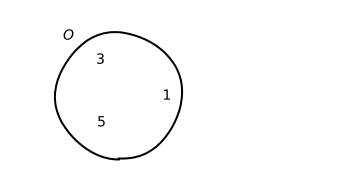

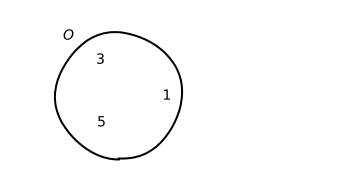

In [2]:
import matplotlib.patches as patches

fig = plt.figure()

values = np.random.permutation((1, 3, 5))

error = lambda x: (np.random.random() - 0.5) * 0.1
errors = np.array([(error(v), error(v)) for v in values])

coords = np.array([(.35 * math.cos(t), .35 * math.sin(t))
          for t in np.linspace(0, 2 * math.pi, 4)[:-1]])

venn2_circles((3, 0, 0))
for v, c in zip(values, coords + errors):
    plt.text(*c, str(v))
    
plt.text(-.5, .5, '$O$')

plt.xlim(-1, 2)
plt.ylim(-.8, .8)


glue("venn-picture", fig, display=False)

```{glue:figure} venn-picture
:figwidth: 100%
:name: "venn"

Un semplice diagramma di Venn per descrivere l'insieme $O = \{ 1, 3, 5, 6 \}$.
```

In particolare, la descrizione tramite i diagrammi di Venn presuppone la conoscenza, in linea di principio, di tutti gli elementi che potrebbero far parte di un insieme. L'insieme di tutti i possibili elementi si indica in genere con il simbolo $\Omega$ che viene chiamato _insieme universo_. Nell'esempio precedente facciamo ovviamente riferimento all'universo $\Omega = \{ 1, 2, 3, 4, 5, 6 \}$, il diagramma di Venn dell'insieme $O$ è visualizzato in modo più corretto nella {numref}`Figura %s <venn-universe>`.

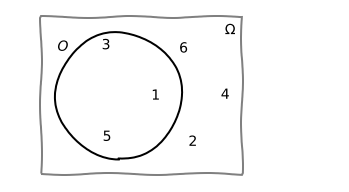

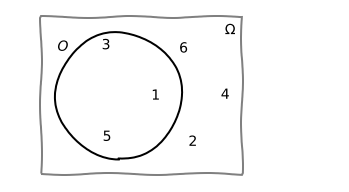

In [3]:
fig = plt.figure()

coords = np.array([(.25 * math.cos(t), .5 * math.sin(t))
          for t in np.linspace(0, 2 * math.pi, 4)[:-1]])

venn2_circles((3, 0, 0))
for v, c in zip(values, coords + errors):
    plt.text(*c, str(v))
    
venn2_circles((3, 0, 0))
for v, c in zip(values, coords + errors):
    plt.text(*c, str(v))

rect = patches.Rectangle((-.7, -.7), 1.8, 1.4, linewidth=2,
                         edgecolor='gray', facecolor='none')
plt.gca().add_patch(rect)

values = np.random.permutation((2, 4, 6))
errors = np.array([(error(v), error(v)) for v in values])

for c in coords:
    c[0] += .7

for v, c in zip(values, coords + errors):
    plt.text(*c, str(v))
    plt.text(*c, str(v))

plt.text(-.55, .4, '$O$')
plt.text(.95, .55, '$\Omega$')

plt.xlim(-1, 2)
plt.ylim(-.8, .8)

glue("venn-universe-picture", fig, display=False)

```{glue:figure} venn-universe-picture
:figwidth: 100%
:name: "venn-universe"

Un diagramma di Venn per descrivere l'insieme $O$ della {numref}`Figura %s <venn>` evidenziando il corrispondente insieme universo $\Omega$.
```

Così come l'insieme universo è tale da contenere qualunque elemento, è matematicamente rilevante pensare ad un insieme che dualmente, non contiene alcun elemento. Tale insieme viene chiamato insieme vuoto, e lo indicheremo scrivendo $\{\}$ (anche se è comune l'uso del simbolo $\varnothing$), così che per qualsiasi elemento $a$ si avrà $a \notin \{\}$.

## Insiemi finiti e infiniti
È abbastanza facile farsi venire in mente degli insiemi che contengono un numero finito di elementi, come ad esempio l'insieme dei membri della Justice League, quello dei giorni della settimana e quello dei numeri primi minori di $100$. Diciamo che insiemi di questo tipo sono _finiti_. Esistono però anche insiemi che non contengono un numero finito di elementi, come l'insieme di tutte le frazioni, o anche l'insieme di tutti gli insiemi. Per questi insiemi _infiniti_ si distinguono due casi:

- si dice che un insieme è _infinito numerabile_ quando risulta possibile costruire una sequenza (infinita) $x_1, x_2, \dots$ che contiene in qualche posizione ognuno dei suoi elementi: l'insieme $D$ dei numeri dispari sopra introdotto è pertanto un insieme infinito numerabile;
- in tutti gli altri casi si dice che l'insieme è _infinito non numerabile:_ l'insieme dei punti di una retta e l'insieme dei numeri reali sono entrambi infiniti e non numerabili.

La modalità di descrizione estensiva non è, strettamente parlando, adottabile per gli insiemi infiniti, visto che per definizione non è possibile elencare tutti i loro elementi. Qaundo però si ha a che fare con un insieme infinito numerabile e quest'ultimo è associabile a una sequenza che si può intuitivamente continuare dopo avere visto solo alcuni tra i suoi elementi iniziali, risulta accettabile estendere la descrizione estensiva elencando solo questi elementi, aggiungendo dei punti di sospensione per enfatizzare la non finitezza dell'insieme. Ad esempio l'insieme dei numeri dispari si può indicare estensivamente come $D = \{1, 3, 5, 7, 9, ... \}$, sebbene la descrizione intensiva

$$D = \{ x \in \mathbb N \text{ tale che }
         x = 2n+1 \text{ per qualche } n \in \mathbb N \}$$

sia decisamente più precisa. Ciò non vale invece per gli insiemi infiniti non numerabili, per i quali sono generalmente utilizzabili sono descrizioni di tipo intensivo.

## Relazioni tra insiemi

Quando ogni elemento sappartenente a un insieme $S$ risulta appartenente anche a un secondo insieme $T$, si dice che $S$ è un _sottoinsieme_ di $T$ (o che $S$ è _incluso_ in $T$) e si indica questo fatto con la notazione $S \subseteq T$:

$$ S \subseteq T \leftrightarrow \forall s (s \in S \rightarrow s \in T) $$

Due insiemi si dicono _uguali_ quando si includono mutuamente; conseguentemente, due insiemi si dicono diversi quando non sono uguali:

$$ S = T \leftrightarrow S \subseteq T \wedge T \subseteq S $$

Tra due insiemi sussiste la relazione di inclusione in senso stretto quando uno dei due è incluso nell'altro e in aggiunta i due insiemi non sono uguali:

$$ S \subset T \leftrightarrow S \subseteq T \wedge T \neq S $$

Si verifica facilmente come qualunque insieme risulti sempre incluso nell'insieme universo, e come analogamente l'insieme vuoto risulti sempre incluso in qualunque insieme:

$$ \forall S \{\} \subseteq S \subseteq \Omega $$

Questa relazione continua a valere se si considera la relazione di inclusione in senso stretto, a patto che $S$ sia diverso dall'insieme vuoto (affinché valga la prima parte della relazione) e dall'insieme universo (affinché possa valere la sua seconda parte).

In [4]:
# FIGURA

## Operazioni tra insiemi

L'_unione_ di due insiemi $S$ e $T$ è costituita dall'insieme $S \cup T$ contenente tutti gli elementi che appartengono ad almeno uno di essi:

$$ S \cup T = \{x \in \Omega | x \in S \vee x \in T \}$$

FIGURA

L'_intersezione_ di due insiemi $S$ e $T$ è costituita dall'insieme $S \cap T$ contenente tutti gli elementi comuni a $S$ e $T$;

$$ S \cap T = \{ x \in \Omega | x \in S \wedge x \in T \} $$

FIGURA

Si verifica facilmente come le operazioni di unione e intersezione siano

- commutative
- associative

La _differenza_ tra un insieme $S$ e un insieme $T$ è costituita dall'insieme $S \backslash T$ contenente tutti gli elementi di $S$ che non appartengono a $T$:

$$ S \backslash T = \{ x \in \Omega | x \in S \wedge x \notin T \} $$

FIGURA

La _differenza simmetrica_ tra due insiemi $S$ e $T$ è costituita dall'insieme $S \ominus T$ contenente tutti gli elementi che appartengono solamente a $S$ o solamente a $T$:

$$ S \ominus T = \{ x \in \Omega | ( x \in S \wedge x \notin T ) \vee ( x \notin S \wedge x \in T) \} $$

FIGURA

Valgono le seguenti relazioni tra la differenza simmetrica, l'unione, l'intersezione e la differenza tra insiemi:

- $S \ominus T = (S \backslash T) \cup (T \backslash S)$,
- $S \ominus T = (S \cup T) \backslash (S \cap T)$.

Il _complemento_ di un insieme $S$ è costituito dall'insieme $\overline S$ contenente tutti gli elementi dell'insieme universo che non appartengono a $S$:

$$ \overline S = \{ x \in \Omega | x \notin S \} = \Omega \backslash S. $$

FIGURA

## Sequenze di insiemi

## Gli insiemi in Python

[^citazione-cantor]: Traduzione dal testo originale "Unter einer 'Mannigfaltigkeit' oder 'Menge' verstee ich nämlich allgemein jedes Viele, welches sich als Eines denken lässt".